# 📈 Notebook 05 — Full Backtest Engine
**LSTM Signal + DQN Action → Portfolio Simulation → Risk Metrics**

Computes:
- CAGR, Sharpe, Sortino, Calmar, Max Drawdown
- Trade-level P&L, Win Rate, Avg Win/Loss ratio
- Benchmark comparison (Buy & Hold)
- Tear-sheet style report


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import pickle, yaml, json
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

BASE_DIR  = Path('.')
DATA_PROC = BASE_DIR / 'data' / 'processed'
RESULTS   = BASE_DIR / 'results'
TRADES    = RESULTS / 'trades'
METRICS   = RESULTS / 'metrics'
TRADES.mkdir(parents=True, exist_ok=True)
METRICS.mkdir(parents=True, exist_ok=True)

with open(BASE_DIR / 'configs' / 'model_config.yaml') as f:
    full_cfg = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')

🖥️  Device: cuda


## 1. Load DQN Eval Data

In [2]:
eval_path = DATA_PROC / 'dqn_eval_portfolio.pkl'
assert eval_path.exists(), '❌ Run 04_dqn_agent.ipynb first!'

with open(eval_path, 'rb') as f:
    eval_data = pickle.load(f)

port_history = np.array(eval_data['port_history'])  # portfolio values over time
action_log   = eval_data['action_log']               # list of actions (0/1/2)
trade_log    = eval_data['trade_log']                # list of (BUY/SELL, step, price, qty)
price_df     = eval_data['price_df']                 # OHLCV DataFrame
initial_cap  = eval_data['initial_cap']

# Align lengths
T = min(len(port_history), len(price_df))
port_history = port_history[:T]
price_series = price_df['close'].values[:T]

print(f'✅ Loaded: {T} timesteps, {len(trade_log)} trades')
print(f'   Initial capital: ${initial_cap:,.0f}')
print(f'   Final value:     ${port_history[-1]:,.0f}')

✅ Loaded: 209 timesteps, 32 trades
   Initial capital: $100,000
   Final value:     $111,621


## 2. Performance Metrics Engine

In [3]:
def compute_metrics(port_values: np.ndarray, initial_cap: float,
                    risk_free: float = 0.05, trading_days: int = 252) -> dict:
    """Comprehensive portfolio performance metrics."""
    returns = np.diff(port_values) / port_values[:-1]
    returns = returns[np.isfinite(returns)]

    total_return = (port_values[-1] - initial_cap) / initial_cap
    n_years      = len(port_values) / trading_days
    cagr         = (port_values[-1] / initial_cap) ** (1 / max(n_years, 0.01)) - 1

    ann_ret    = returns.mean() * trading_days
    ann_vol    = returns.std()  * np.sqrt(trading_days)
    sharpe     = (ann_ret - risk_free) / (ann_vol + 1e-8)

    neg_rets   = returns[returns < 0]
    sortino_d  = neg_rets.std() * np.sqrt(trading_days) + 1e-8
    sortino    = (ann_ret - risk_free) / sortino_d

    # Max Drawdown
    peak       = np.maximum.accumulate(port_values)
    drawdown   = (port_values - peak) / peak
    max_dd     = drawdown.min()
    calmar     = cagr / abs(max_dd + 1e-8)

    # Win/Loss rate
    pos_rets = returns[returns > 0]
    neg_rets = returns[returns < 0]
    win_rate = len(pos_rets) / max(len(returns), 1)
    avg_win  = pos_rets.mean() if len(pos_rets) > 0 else 0.0
    avg_loss = neg_rets.mean() if len(neg_rets) > 0 else 0.0
    profit_factor = (pos_rets.sum()) / (abs(neg_rets.sum()) + 1e-8)

    # VaR / CVaR (95%)
    var_95  = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean() if any(returns <= var_95) else var_95

    return {
        'total_return':  round(total_return * 100, 2),
        'cagr':          round(cagr * 100, 2),
        'ann_volatility':round(ann_vol * 100, 2),
        'sharpe':        round(float(sharpe), 3),
        'sortino':       round(float(sortino), 3),
        'calmar':        round(float(calmar), 3),
        'max_drawdown':  round(max_dd * 100, 2),
        'win_rate':      round(win_rate * 100, 2),
        'avg_win_pct':   round(avg_win * 100, 4),
        'avg_loss_pct':  round(avg_loss * 100, 4),
        'profit_factor': round(float(profit_factor), 3),
        'var_95':        round(var_95 * 100, 3),
        'cvar_95':       round(cvar_95 * 100, 3),
        'final_value':   round(float(port_values[-1]), 2),
    }

# Strategy metrics
strategy_metrics = compute_metrics(port_history, initial_cap)

# Buy & Hold benchmark
bnh_values = initial_cap * (price_series / price_series[0])
bnh_metrics = compute_metrics(bnh_values, initial_cap)

print('\n📊 PERFORMANCE REPORT')
print('=' * 55)
print(f'{"Metric":<22} {"DQN Strategy":>14} {"Buy & Hold":>14}')
print('-' * 55)
for key in ['total_return','cagr','ann_volatility','sharpe','sortino',
            'calmar','max_drawdown','win_rate','profit_factor','var_95','cvar_95']:
    unit = '%' if 'return' in key or 'volatility' in key or 'drawdown' in key or 'rate' in key or 'var' in key else ''
    s_val = f"{strategy_metrics[key]}{unit}"
    b_val = f"{bnh_metrics[key]}{unit}"
    print(f'  {key:<20} {s_val:>14} {b_val:>14}')

# Save metrics
all_metrics = {'strategy': strategy_metrics, 'buy_and_hold': bnh_metrics,
               'generated_at': datetime.now().isoformat()}
with open(METRICS / 'performance_report.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print('\n✅ Metrics saved → results/metrics/performance_report.json')


📊 PERFORMANCE REPORT
Metric                   DQN Strategy     Buy & Hold
-------------------------------------------------------
  total_return                 11.62%         22.64%
  cagr                          14.17           27.9
  ann_volatility                8.73%         11.56%
  sharpe                        0.997          1.766
  sortino                       1.128          2.508
  calmar                        4.818          5.502
  max_drawdown                 -2.94%         -5.07%
  win_rate                     42.31%         56.73%
  profit_factor                 1.358          1.452
  var_95                      -0.796%          -1.1%
  cvar_95                     -1.384%        -1.586%

✅ Metrics saved → results/metrics/performance_report.json


## 3. Trade Log Analysis

In [4]:
# Build trade P&L pairs
trade_pnl = []
buys  = [(s, p, q) for t, s, p, q in trade_log if t == 'BUY']
sells = [(s, p, q) for t, s, p, q in trade_log if t == 'SELL']

for (bs, bp, bq), (ss, sp, sq) in zip(buys, sells):
    qty    = min(bq, sq)
    pnl    = (sp - bp) * qty
    pnl_pct= (sp - bp) / bp * 100
    dur    = ss - bs
    trade_pnl.append({'entry_step': bs, 'exit_step': ss, 'entry_price': bp,
                      'exit_price': sp, 'qty': qty, 'pnl': pnl,
                      'pnl_pct': pnl_pct, 'duration': dur})

trade_df = pd.DataFrame(trade_pnl)

if len(trade_df) > 0:
    winners = trade_df[trade_df['pnl'] > 0]
    losers  = trade_df[trade_df['pnl'] <= 0]
    print(f'📋 Completed Trades : {len(trade_df)}')
    print(f'   Winners          : {len(winners)} ({len(winners)/len(trade_df)*100:.1f}%)')
    print(f'   Losers           : {len(losers)} ({len(losers)/len(trade_df)*100:.1f}%)')
    print(f'   Avg Win P&L      : ${winners["pnl"].mean():,.0f} ({winners["pnl_pct"].mean():+.2f}%)') if len(winners) > 0 else None
    print(f'   Avg Loss P&L     : ${losers["pnl"].mean():,.0f} ({losers["pnl_pct"].mean():+.2f}%)') if len(losers) > 0 else None
    print(f'   Total P&L        : ${trade_df["pnl"].sum():,.0f}')
    print(f'   Avg Hold Duration: {trade_df["duration"].mean():.1f} steps')
    trade_df.to_csv(TRADES / 'trade_log.csv', index=False)
    print('\n✅ Trade log saved → results/trades/trade_log.csv')
else:
    print('⚠️  No completed round-trip trades found.')

📋 Completed Trades : 4
   Winners          : 4 (100.0%)
   Losers           : 0 (0.0%)
   Avg Win P&L      : $2,393 (+12.57%)
   Total P&L        : $9,574
   Avg Hold Duration: 113.5 steps

✅ Trade log saved → results/trades/trade_log.csv


## 4. Equity Curve + Drawdown Chart

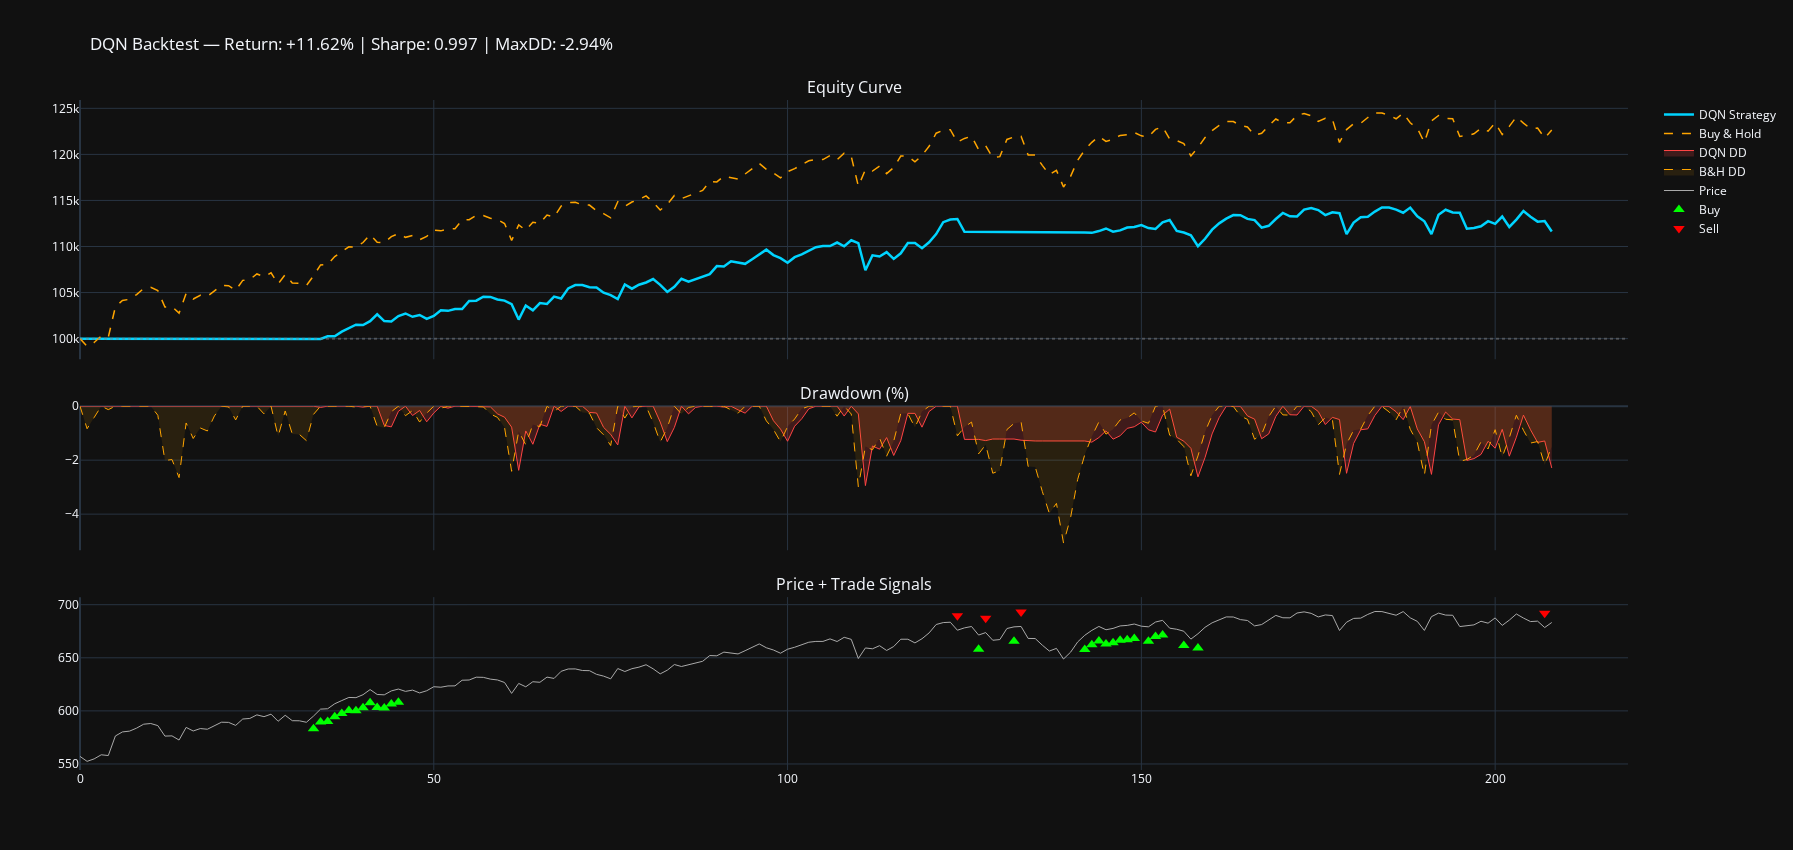

✅ Equity curve saved → results/metrics/equity_curve.html


In [5]:
peak_strat = np.maximum.accumulate(port_history)
dd_strat   = (port_history - peak_strat) / peak_strat * 100

peak_bnh = np.maximum.accumulate(bnh_values)
dd_bnh   = (bnh_values - peak_bnh) / peak_bnh * 100

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=['Equity Curve', 'Drawdown (%)', 'Price + Trade Signals'],
    vertical_spacing=0.07,
    row_heights=[0.45, 0.25, 0.30]
)

steps = list(range(T))

# Equity curves
fig.add_trace(go.Scatter(x=steps, y=port_history,
                          line=dict(color='#00d4ff', width=2.5), name='DQN Strategy'), row=1, col=1)
fig.add_trace(go.Scatter(x=steps, y=bnh_values,
                          line=dict(color='#ffa500', width=1.5, dash='dash'), name='Buy & Hold'), row=1, col=1)
fig.add_hline(y=initial_cap, line_dash='dot', line_color='gray', opacity=0.5, row=1, col=1)

# Drawdown
fig.add_trace(go.Scatter(x=steps, y=dd_strat, fill='tozeroy',
                          line=dict(color='#ff4444', width=1), fillcolor='rgba(255,68,68,0.2)',
                          name='DQN DD'), row=2, col=1)
fig.add_trace(go.Scatter(x=steps, y=dd_bnh, fill='tozeroy',
                          line=dict(color='#ffa500', width=1, dash='dash'), fillcolor='rgba(255,165,0,0.1)',
                          name='B&H DD'), row=2, col=1)

# Price + signals
buy_steps  = [s for t,s,p,q in trade_log if t=='BUY'  and s < T]
sell_steps = [s for t,s,p,q in trade_log if t=='SELL' and s < T]
buy_prices  = [price_series[s] for s in buy_steps]
sell_prices = [price_series[s] for s in sell_steps]

fig.add_trace(go.Scatter(x=steps[:len(price_series)], y=price_series,
                          line=dict(color='#aaaaaa', width=1), name='Price'), row=3, col=1)
fig.add_trace(go.Scatter(x=buy_steps, y=[p*0.98 for p in buy_prices], mode='markers',
                          marker=dict(symbol='triangle-up', size=10, color='lime'), name='Buy'), row=3, col=1)
fig.add_trace(go.Scatter(x=sell_steps, y=[p*1.02 for p in sell_prices], mode='markers',
                          marker=dict(symbol='triangle-down', size=10, color='red'), name='Sell'), row=3, col=1)

fig.update_layout(
    height=850, template='plotly_dark',
    title=f'DQN Backtest — Return: {strategy_metrics["total_return"]:+.2f}% | '
          f'Sharpe: {strategy_metrics["sharpe"]:.3f} | MaxDD: {strategy_metrics["max_drawdown"]:.2f}%',
    showlegend=True
)
fig.show()
fig.write_html(str(METRICS / 'equity_curve.html'))
print('✅ Equity curve saved → results/metrics/equity_curve.html')

## 5. Monthly Returns Heatmap

In [6]:
# Build daily returns series
daily_rets = pd.Series(
    np.diff(port_history) / port_history[:-1],
    name='returns'
)

# Try to attach dates from price_df index
if hasattr(price_df.index, 'dtype') and str(price_df.index.dtype).startswith('datetime'):
    dates = price_df.index[:len(daily_rets)]
    daily_rets.index = dates
    monthly = daily_rets.resample('ME').apply(lambda x: (1 + x).prod() - 1)

    pivot = pd.DataFrame({
        'year':  monthly.index.year,
        'month': monthly.index.month,
        'ret':   monthly.values * 100
    }).pivot(index='year', columns='month', values='ret')
    pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

    fig_hm, ax = plt.subplots(figsize=(14, max(3, len(pivot))))
    sns.heatmap(pivot, annot=True, fmt='.1f', center=0,
                cmap='RdYlGn', linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Return (%)'})
    ax.set_title('Monthly Returns Heatmap (%)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(METRICS / 'monthly_returns_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Monthly heatmap saved.')
else:
    print('⚠️  Price index is not DatetimeIndex — skipping monthly heatmap.')

⚠️  Price index is not DatetimeIndex — skipping monthly heatmap.


## 6. Rolling Sharpe

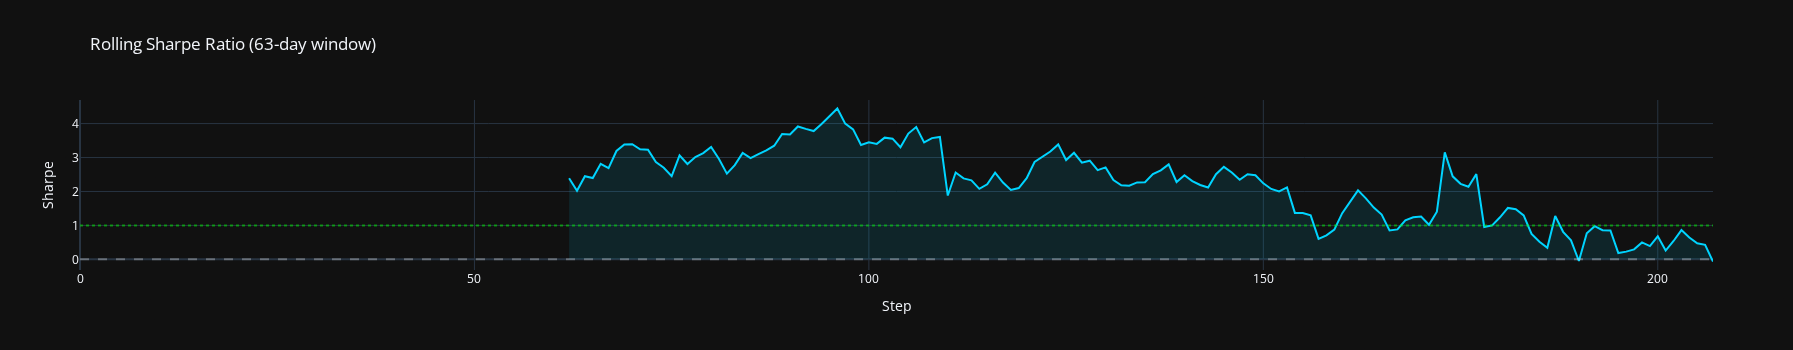

✅ Rolling Sharpe saved.


In [7]:
rets = pd.Series(np.diff(port_history) / port_history[:-1])
WINDOW = 63  # ~3 months

roll_sharpe = (
    rets.rolling(WINDOW).mean() /
    (rets.rolling(WINDOW).std() + 1e-8)
) * np.sqrt(252)

fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    y=roll_sharpe.tolist(),
    mode='lines', line=dict(color='#00d4ff', width=2),
    name='Rolling Sharpe (63d)',
    fill='tozeroy', fillcolor='rgba(0,212,255,0.1)'
))
fig2.add_hline(y=0, line_dash='dash', line_color='white', opacity=0.3)
fig2.add_hline(y=1, line_dash='dot', line_color='lime', opacity=0.5)
fig2.update_layout(template='plotly_dark', title='Rolling Sharpe Ratio (63-day window)',
                   xaxis_title='Step', yaxis_title='Sharpe', height=350)
fig2.show()
fig2.write_html(str(METRICS / 'rolling_sharpe.html'))
print('✅ Rolling Sharpe saved.')